## Sleep, Screen Time and Stress Analysis Dataset

In [42]:
import warnings
warnings.filterwarnings("ignore")

In [81]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [44]:
RANDOM_STATE = 42

In [45]:
#Считываем набор данных

df_stress = pd.read_csv("sleep_mobile_stress_dataset_15000.csv")
df_stress

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,39,Male,Manager,8.05,45,8.91,4.33,10.00,1,40,259,10.00
14996,14997,22,Female,Student,6.44,80,6.00,5.22,10.00,2,41,231,7.54
14997,14998,51,Female,Software Engineer,7.01,78,7.27,5.37,8.66,4,93,288,7.78
14998,14999,56,Female,Software Engineer,7.89,6,5.70,5.71,9.56,1,91,47,9.98


In [46]:
#Определим типы признаков в датасете

df_stress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [47]:
#Посмотрим на число уникальных значений в каждом признаке

df_stress.nunique()

user_id                             15000
age                                    42
gender                                  3
occupation                              8
daily_screen_time_hours               901
phone_usage_before_sleep_minutes      120
sleep_duration_hours                  501
sleep_quality_score                   831
stress_level                          900
caffeine_intake_cups                    5
physical_activity_minutes             120
notifications_received_per_day        280
mental_fatigue_score                  901
dtype: int64

In [48]:
#Посмотрим на статистическую сводку по данным

df_stress.describe(include="all")

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
unique,NaN,NaN,3,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,Manager,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,7234,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7500.500000,38.488467,NaN,NaN,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,NaN,NaN,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,NaN,NaN,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,NaN,NaN,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,NaN,NaN,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,NaN,NaN,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000


In [49]:
#Проверим на столбцы в датасете

df_stress.columns

Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

In [50]:
#Посмотрим на количество пропусков по каждому столбцу

df_stress.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [51]:
#Посмотрим на количество дубликатов в датасете

df_stress.duplicated().sum()

np.int64(0)

In [52]:
#Посмотрим на распределение целевой переменной

print(df_stress["stress_level"].value_counts())
print(df_stress["stress_level"].unique())

stress_level
10.00    3875
1.00      250
5.98       28
9.76       27
5.32       26
         ... 
1.60        2
1.37        2
1.64        1
1.05        1
1.03        1
Name: count, Length: 900, dtype: int64
[ 3.49  3.01  5.03 10.    6.71  5.38  3.48  3.46  7.9   5.23  1.87  7.93
  8.09  5.35  4.36  6.99  7.48  2.94  2.64  8.99  1.    4.73  8.95  6.95
  7.26  9.62  4.48  4.18  5.59  2.37  4.56  8.33  1.5   7.76  3.92  1.91
  6.51  4.85  6.43  9.21  1.53  4.19  9.74  4.65  6.38  3.    2.43  3.94
  3.83  9.1   9.38  4.44  6.45  6.97  9.92  8.04  3.19  4.87  6.02  4.32
  9.2   7.39  5.67  4.26  7.51  2.71  5.06  9.51  3.26  4.38  2.74  9.17
  5.46  5.    3.28  2.57  9.16  8.59  4.53  7.95  1.49  9.32  4.21  3.61
  4.68  3.9   7.01  1.44  7.36  2.72  2.96  3.8   8.14  5.21  4.54  8.53
  9.99  5.3   4.11  8.76  7.92  9.63  3.84  9.98  6.77  1.03  7.38  3.37
  3.34  5.63  2.15  9.76  9.59  9.22  4.55  4.13  6.48  8.39  4.45  5.66
  4.76  7.43  8.26  8.92  2.47  6.73  8.83  3.09  5.55  8.88  6.

По распределению целевой перменной можно заметить, что большинство людей имеют довольно высокий уровень стресса. Для классификации уровня стресса будем использовать биннинг.

In [53]:
df_stress["stress_category"] = pd.cut(df_stress["stress_level"], bins=[1, 4, 7, 10], labels=["low", "medium", "high"], include_lowest=True)

In [54]:
print(df_stress["stress_category"].value_counts(normalize=True))
print(df_stress["stress_category"].unique())

stress_category
high      0.538467
medium    0.279267
low       0.182267
Name: proportion, dtype: float64
['low', 'medium', 'high']
Categories (3, object): ['low' < 'medium' < 'high']


Можно заметить, что в данных присутствует дисбаланс классов. Поэтому при работе с данными будем использовать такие метрики как: F1 score, Precision, Recall, ROC-AUC. Также задействуем параметр class_weight="balanced" в моделях Логистической регрессии и Случайном лесе. 

In [55]:
print(df_stress["gender"].value_counts())

gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64


In [56]:
#Проводим очистку данных от ненужных признаков

df_stress = df_stress.drop(["user_id"], axis=1)
df_stress = df_stress.drop(["stress_level"], axis=1)

In [57]:
#Выделим целевую переменную

X = df_stress.drop(columns=["stress_category"])
y = df_stress["stress_category"]

In [58]:
#Проводим очистку данных от ненужных признаков, а также выделим числовые и категориальные переменные.

cat_features = X.select_dtypes(include=["object", "bool", "category"]).columns
num_features = X.select_dtypes(include=["float64", "int64"]).columns

## EDA

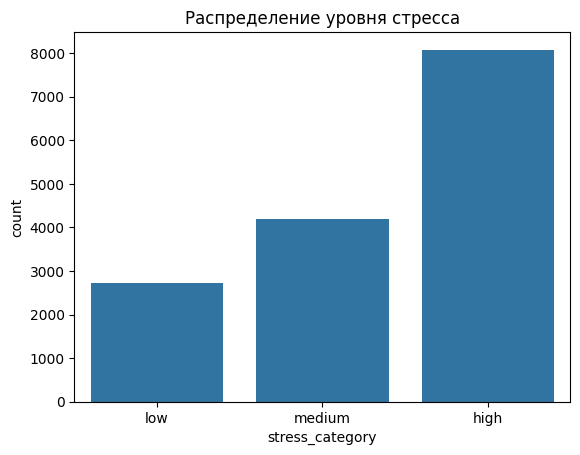

In [ ]:
sns.countplot(x=y)

plt.title("Распределение уровня стресса")
plt.show()

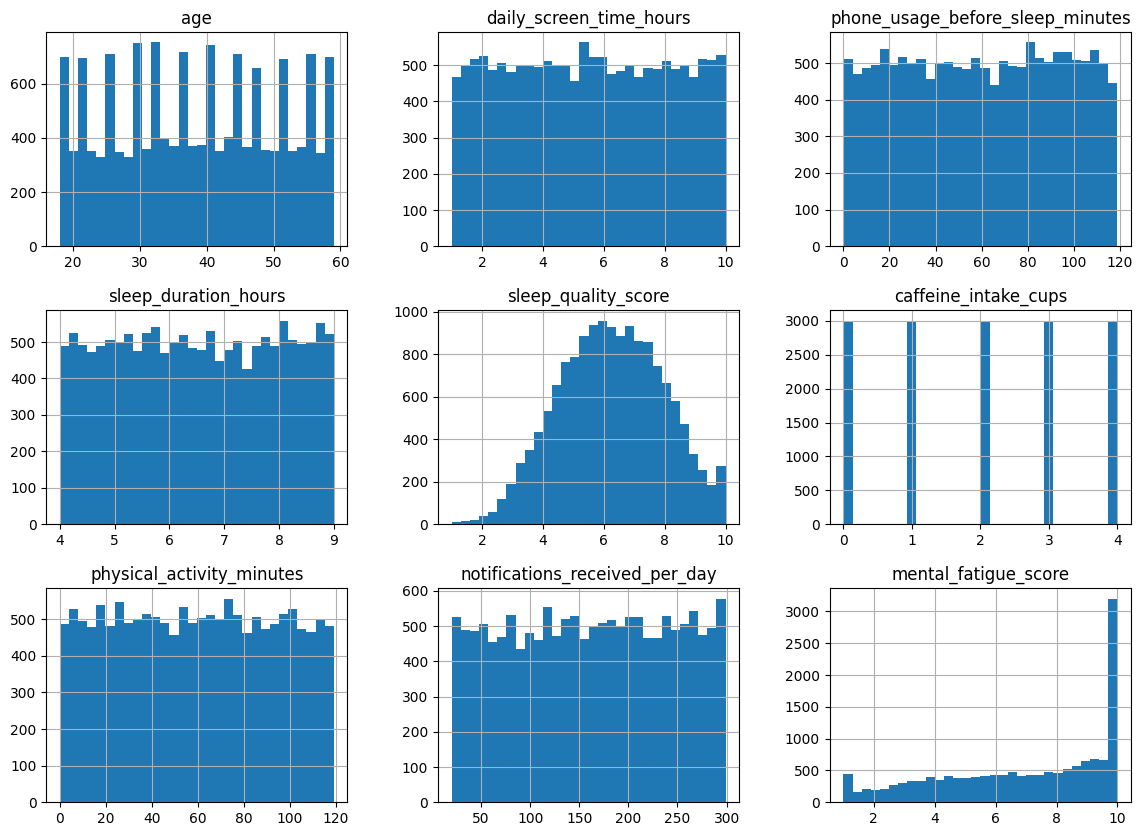

In [62]:
X[num_features].hist(figsize=(14, 10), bins=30)

plt.tight_layout
plt.show()

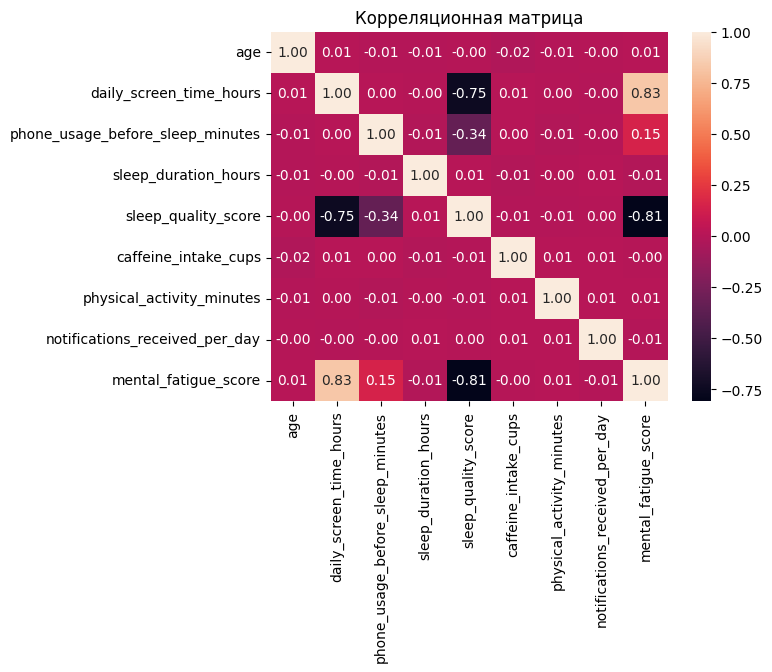

In [65]:
sns.heatmap(
    X[num_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Корреляционная матрица")
plt.show()

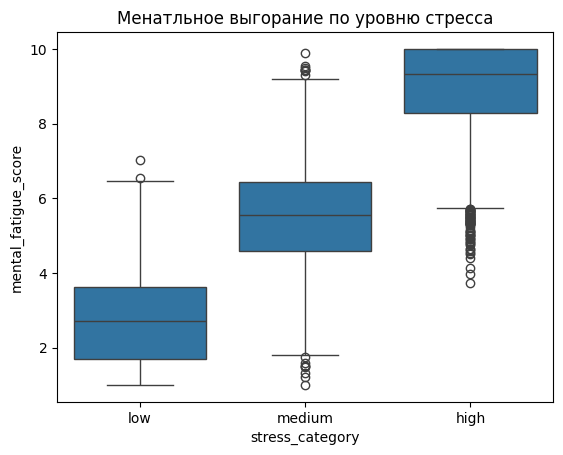

In [67]:
sns.boxplot(
    x=y, 
    y=X["mental_fatigue_score"]
)

plt.title("Менатльное выгорание по уровню стресса")
plt.show()

Вывод по проведенному EDA:
1) В данных присутствует дисбаланс классов. В основном доминирует класс "high", который говорит, что людей с высоким уровнем стресса больше всего.

2) По матрице корреляции и гистограмме видно, что много времени за экраном телефона ведет к ухудшению качества сна, плохой сон ведет к ментальному выгоранию, а высокое выгорание сильно коррелирует с высоким уровнем стресса.

3) Видно, что признак mental_fatigue_score будет являться главным признаком для моделей. 

4) По "ящику с усами" можно заметить, что у тех людей, у кого высокий уровень стресса, имеют и другие причины иметь высокие уровень стресса помимо ментального выгорания.


## Постройка пайплайна для моделей

In [68]:
# Разделим датасет на обучающую (70%) и тестовую (30%) выборки со стратификацией по целевой переменной

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

In [ ]:
#Построим пайплайн для базовой модели Логистической регрессии

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

pipe_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"))
    ]
)

pipe_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
print(classification_report(y_test, pipe_lr.predict(X_test), digits=4))

              precision    recall  f1-score   support

        high     0.9696    0.9199    0.9441      2423
         low     0.8255    0.9000    0.8611       820
      medium     0.7888    0.8202    0.8042      1257

    accuracy                         0.8884      4500
   macro avg     0.8613    0.8800    0.8698      4500
weighted avg     0.8928    0.8884    0.8899      4500



In [75]:
print(roc_auc_score(y_test, pipe_lr.predict_proba(X_test), multi_class="ovr"))

0.978535356710764


In [77]:
#Построим пайплайн для базового Случайного леса

pipe_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
    ]
)

pipe_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
print(classification_report(y_test, pipe_rf.predict(X_test), digits=4))

              precision    recall  f1-score   support

        high     0.9446    0.9509    0.9478      2423
         low     0.8533    0.8512    0.8523       820
      medium     0.8061    0.7971    0.8016      1257

    accuracy                         0.8898      4500
   macro avg     0.8680    0.8664    0.8672      4500
weighted avg     0.8893    0.8898    0.8895      4500



In [79]:
print(roc_auc_score(y_test, pipe_rf.predict_proba(X_test), multi_class="ovr"))

0.9759829597087523


In [84]:
print(y_train.value_counts())
print(y_train.value_counts().sum())

stress_category
high      5654
medium    2932
low       1914
Name: count, dtype: int64
10500


In [83]:
#Построим пайплайн для базовой модели CatBoost

pipe_catb = Pipeline(
    steps=[
        ("model", CatBoostClassifier(
            random_state=RANDOM_STATE, 
            class_weights={"low": 5.48, "medium": 3.58, "high": 1.85}, 
            cat_features=list(cat_features), 
            verbose=0
        ))
    ]
)

pipe_catb.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False


In [85]:
print(classification_report(y_test, pipe_catb.predict(X_test), digits=4))

              precision    recall  f1-score   support

        high     0.9599    0.9286    0.9440      2423
         low     0.8412    0.8720    0.8563       820
      medium     0.7871    0.8178    0.8022      1257

    accuracy                         0.8873      4500
   macro avg     0.8627    0.8728    0.8675      4500
weighted avg     0.8900    0.8873    0.8884      4500



In [89]:
catboost_order = list(pipe_catb.named_steps["model"].classes_)
sklearn_order = sorted(catboost_order)

proba = pipe_catb.predict_proba(X_test)
reordered_proba = proba[:, [catboost_order.index(c) for c in sklearn_order]]

print(roc_auc_score(y_test, reordered_proba, multi_class="ovr"))

0.97626171696251
